#  Topic Modeling Results



In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import text
import database as db

pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Topic Size Distribution

Total topics: 24
Total articles covered: 16,792


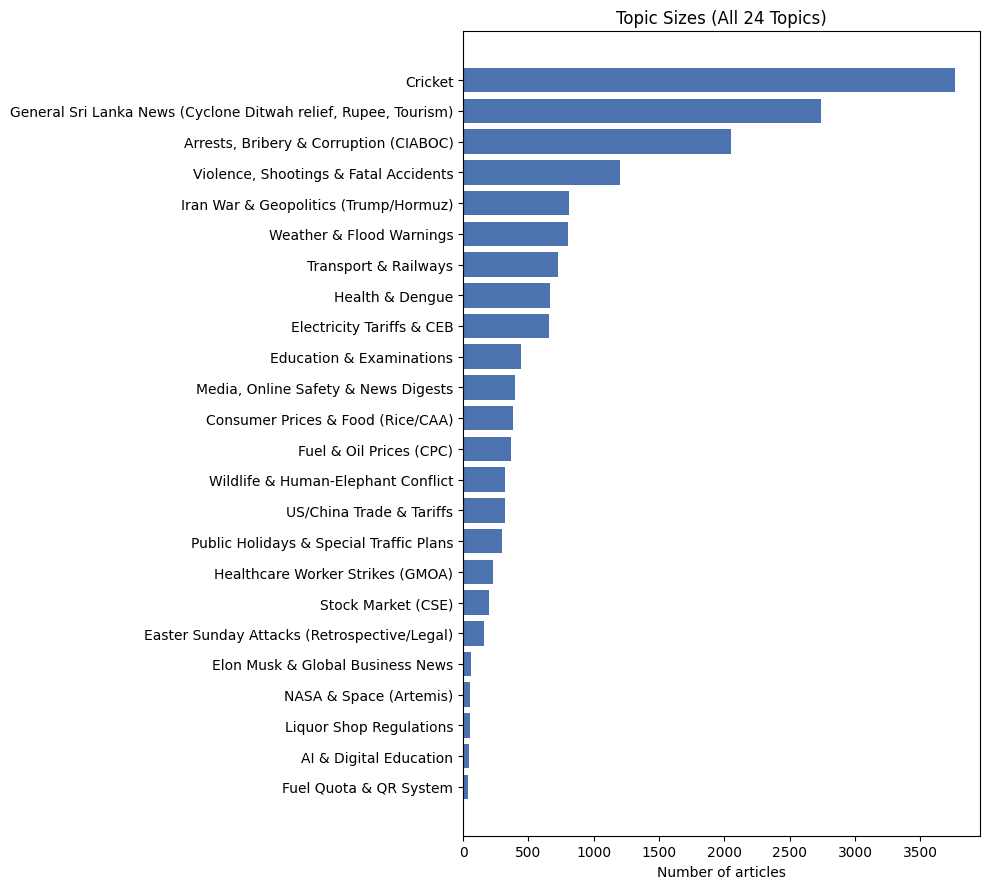

In [2]:
with db.get_connection() as conn:
    topic_sizes = pd.read_sql(text('''
        SELECT topic_name, COUNT(*) as article_count
        FROM article_topics
        GROUP BY topic_name
        ORDER BY article_count DESC
    '''), conn)

print(f"Total topics: {len(topic_sizes)}")
print(f"Total articles covered: {topic_sizes['article_count'].sum():,}")

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(topic_sizes['topic_name'][::-1], topic_sizes['article_count'][::-1], color='#4C72B0')
ax.set_xlabel('Number of articles')
ax.set_title('Topic Sizes (All 24 Topics)')
plt.tight_layout()
plt.show()

## 2. Full Topic Table

In [3]:
topic_sizes['pct'] = (topic_sizes['article_count'] / topic_sizes['article_count'].sum() * 100).round(1)
topic_sizes

,topic_name,article_count,pct
0,Cricket,3768,22.4
1,"General Sri Lanka News (Cyclone Ditwah relief, Rupee, Tourism)",2739,16.3
2,"Arrests, Bribery & Corruption (CIABOC)",2051,12.2
3,"Violence, Shootings & Fatal Accidents",1204,7.2
4,Iran War & Geopolitics (Trump/Hormuz),809,4.8
5,Weather & Flood Warnings,805,4.8
6,Transport & Railways,726,4.3
7,Health & Dengue,667,4.0
8,Electricity Tariffs & CEB,657,3.9
9,Education & Examinations,442,2.6


## 3. Tracked Topic Frequency Over Time

The 7 topics chosen for individual tracking in `temporal_analysis.py`, plotted weekly.

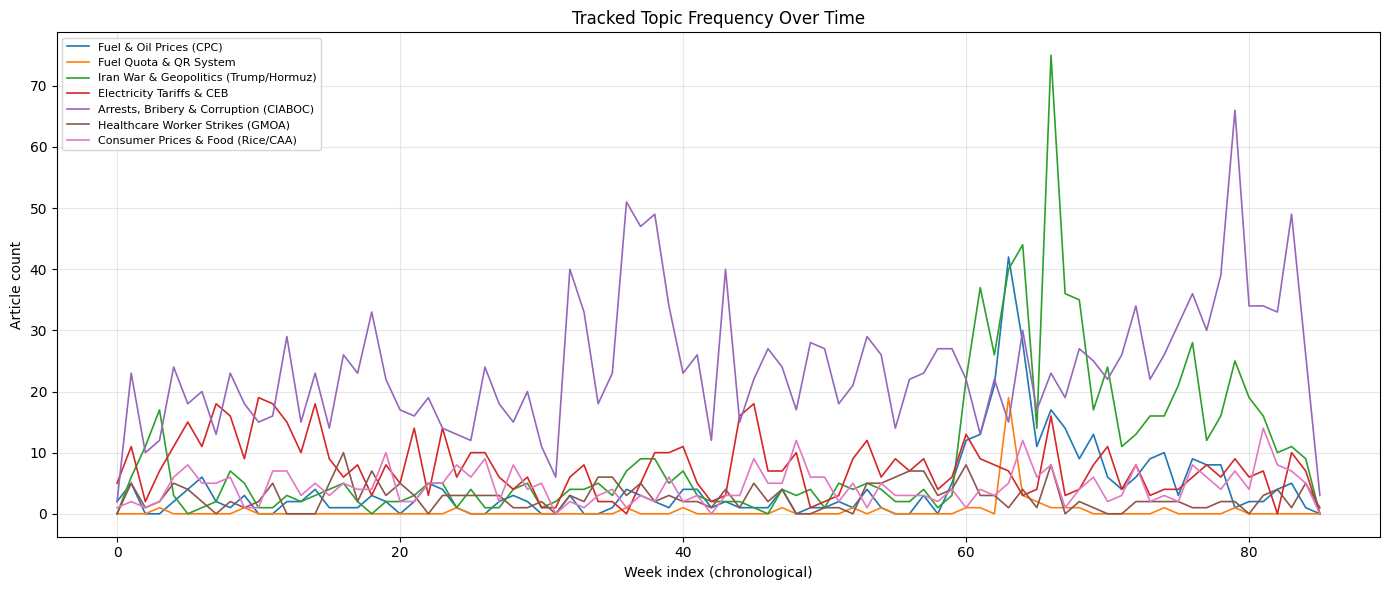

In [4]:
TRACKED = [
    'Fuel & Oil Prices (CPC)', 'Fuel Quota & QR System',
    'Iran War & Geopolitics (Trump/Hormuz)',
    'Electricity Tariffs & CEB',
    'Arrests, Bribery & Corruption (CIABOC)',
    'Healthcare Worker Strikes (GMOA)',
    'Consumer Prices & Food (Rice/CAA)',
]

with db.get_connection() as conn:
    tracked_weekly = pd.read_sql(text('''
        SELECT pn.publication_week AS week, t.topic_name, COUNT(*) as cnt
        FROM article_topics t
        JOIN processed_news pn ON t.article_id = pn.article_id
        WHERE pn.duplicate_status != 'EXACT_DUPLICATE'
        GROUP BY pn.publication_week, t.topic_name
        ORDER BY pn.publication_week
    '''), conn)

pivot = tracked_weekly.pivot(index='week', columns='topic_name', values='cnt').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for topic in TRACKED:
    if topic in pivot.columns:
        ax.plot(range(len(pivot)), pivot[topic].values, label=topic, linewidth=1.2)

ax.set_xlabel('Week index (chronological)')
ax.set_ylabel('Article count')
ax.set_title('Tracked Topic Frequency Over Time')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Zoomed View: Crisis Period (2025-W40 to 2026-W20)

The same chart, cropped to the window covering both Cyclone Ditwah and the Fuel Crisis.

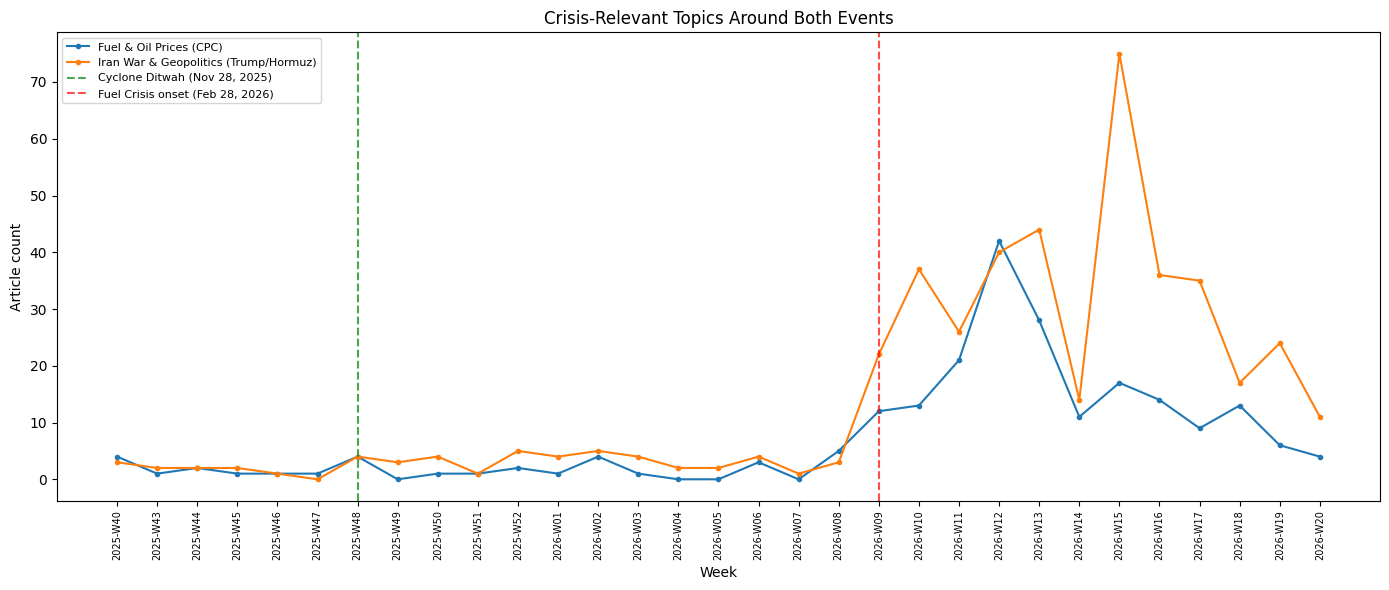

In [5]:
crisis_window = pivot[(pivot.index >= '2025-W40') & (pivot.index <= '2026-W20')]

fig, ax = plt.subplots(figsize=(14, 6))
key_topics = ['Fuel & Oil Prices (CPC)', 'Iran War & Geopolitics (Trump/Hormuz)']
for topic in key_topics:
    if topic in crisis_window.columns:
        ax.plot(crisis_window.index, crisis_window[topic].values, marker='o', markersize=3, label=topic)

ax.axvline('2025-W48', color='green', linestyle='--', alpha=0.7, label='Cyclone Ditwah (Nov 28, 2025)')
ax.axvline('2026-W09', color='red', linestyle='--', alpha=0.7, label='Fuel Crisis onset (Feb 28, 2026)')
ax.set_xlabel('Week')
ax.set_ylabel('Article count')
ax.set_title('Crisis-Relevant Topics Around Both Events')
ax.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()